# Implementing the libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import time
import random

# 1. Abstract

In this notebook, we study the [Knight's Tour](https://en.wikipedia.org/wiki/Knight%27s_tour) problem, which asks whether a knight can move across an $n \times n$ chessboard so that every square is visited exactly once. We present the problem from a mathematical perspective by modeling the chessboard as a graph, where each square is represented by a vertex and each legal knight move by an edge. In this setting, an open knight's tour corresponds to a Hamiltonian path, while a closed knight's tour corresponds to a Hamiltonian cycle.

To investigate the problem computationally, we implement and compare three different approaches: a backtracking algorithm, Warnsdorff's heuristic, and a neural-network-based method inspired by the formulation presented on the Knight's Tour Wikipedia page. The methods are evaluated primarily in terms of runtime, while also considering their practical reliability and scalability as the board size increases.

Our main focus is on the open knight's tour problem on $8 \times 8$ chessboard and visualizing it's solution. In the final part of the notebook, we apply the most effective method to construct closed knight's tours.

# 2. Methods

## 2.1. How the knight moves

A knight moves in an $L$-shape: two squares in one direction and one square in the perpendicular direction. If a square is represented by coordinates $(x,y)$, then the set of all legal knight moves is

$$\mathcal{M}=\{(\pm 1,\pm 2),(\pm 2,\pm 1)\}.$$

Thus, from a square $(x,y)$, the knight may move to any square of the form

$$(x,y) + m, \qquad m \in \mathcal{M},$$

provided that the destination square still lies within the board.

For an $n \times n$ chessboard, we define the set of board squares by

$$V_n = \{(i,j)\mid 1 \leq i,j \leq n\}.$$

Two squares $(i,j)$ and $(k,\ell)$ are adjacent if and only if

$$(k-i,\ell-j)\in \mathcal{M}.$$

This allows us to define the **knight graph**

$$G_n = (V_n,E_n),$$

where each vertex corresponds to a square of the board, and each edge corresponds to a legal knight move.

In [15]:
KNIGHT_STEPS = [(2,1),(1,2),(-1,2),(-2,1),(-2,-1),(-1,-2),(1,-2),(2,-1)]

## 2.2. Open and closed knight's tours

A knight's tour is a sequence of distinct squares

$$v_1,v_2,\dots,v_{n^2}, \qquad v_k \in V_n,$$

such that each consecutive pair is connected by a legal knight move:

$$\{v_k,v_{k+1}\}\in E_n, \qquad k=1,2,\dots,n^2-1.$$

### Open knight's tour

An **open knight's tour** is a sequence

$$v_1,v_2,\dots,v_{n^2}$$

such that

$$v_i \neq v_j \quad \text{for } i\neq j,$$

and

$$\{v_k,v_{k+1}\}\in E_n\quad \text{for all } k=1,\dots,n^2-1.$$

Since every square is visited exactly once, an open knight's tour is exactly a **Hamiltonian path** in the knight graph $G_n$.

### Closed knight's tour

A **closed knight's tour** is an open knight's tour with the additional property that the final square is also a legal knight move away from the starting square:

$$\{v_{n^2},v_1\}\in E_n.$$

Therefore, a closed knight's tour is exactly a **Hamiltonian cycle** in the knight graph $G_n$.


In [16]:
def all_squares(n):
    """
    Return all squares of an n x n chessboard using 0-based indexing.

    Parameters
    ----------
    n : int - Board dimension.

    Returns
    -------
    list[tuple[int, int]] - List of coordinates (i, j) for all board squares.
    """
    return [(row, column) for row in range(n) for column in range(n)]

In [17]:
def legal_moves(n, square):
    """
    Return all legal knight moves from a given square on an n x n board.

    Parameters
    ----------
    n : int - Board dimension.
    square : tuple[int, int] - Current square (row, column).

    Returns
    -------
    list[tuple[int, int]] - List of reachable squares by one legal knight move.
    """
    row, column = square
    moves = []
    for drow, dcolumn in KNIGHT_STEPS:
        res_row, res_column = row + drow, column + dcolumn
        if 0 <= res_row < n and 0 <= res_column < n:
            moves.append((res_row, res_column))
    return moves

In [18]:
def knight_graph(n):
    """
    Construct the knight graph of an n x n board.

    Each square is a vertex, and edges connect squares that differ by a legal knight move.

    Parameters
    ----------
    n : int - Board dimension.

    Returns
    -------
    dict[tuple[int, int], list[tuple[int, int]]] - Adjacency dictionary of the knight graph.
    """
    return {tile: legal_moves(n, tile) for tile in all_squares(n)}

In [19]:
def is_knight_move(a, b):
    """
    Check whether moving from square a to square b is a legal knight move.

    Parameters
    ----------
    a : tuple[int, int] - Starting square.
    b : tuple[int, int] - Destination square.

    Returns
    -------
    bool - True if b is reachable from a by one knight move, otherwise False.
    """
    drow = abs(a[0] - b[0])
    dcolumn = abs(a[1] - b[1])
    return sorted((drow, dcolumn)) == [1, 2]

In [20]:
def is_valid_tour(tour, n, closed = False):
    """
    Check whether a sequence of squares is a valid knight's tour on an n x n board.

    A valid tour must:
    - contain exactly n^2 squares,
    - visit each square exactly once,
    - stay inside the board,
    - move by legal knight moves between consecutive squares.

    If closed = True, the final square must also be a legal knight move away
    from the starting square.

    Parameters
    ----------
    tour : list[tuple[int, int]] or None - Candidate tour.
    n : int - Board dimension.
    closed : bool, default=False - Whether to require a closed tour.

    Returns
    -------
    bool - True if the sequence is a valid tour, otherwise False.
    """
    if tour is None or len(tour) != n * n:
        return False
    if len(set(tour)) != n * n:
        return False
    if any(not (0 <= row < n and 0 <= column < n) for row, column in tour):
        return False
    if any(not is_knight_move(tour[i], tour[i + 1]) for i in range(len(tour) - 1)):
        return False
    if closed and not is_knight_move(tour[-1], tour[0]):
        return False
    return True


In [21]:
def open_tour_exists_square(n):
    """
    Return whether an open knight's tour exists on an n x n square board.

    Classical existence result:
    - True for n = 1
    - True for all n >= 5
    - False for n = 2, 3, 4

    Parameters
    ----------
    n : int - Board dimension.

    Returns
    -------
    bool - True if an open tour exists, otherwise False.
    """
    return n == 1 or n >= 5

In [22]:
def closed_tour_exists_square(n):
    """
    Return whether a closed knight's tour exists on an n x n square board.

    Classical existence result:
    - A closed tour exists iff n >= 6 and n is even.

    Parameters
    ----------
    n : int - Board dimension.

    Returns
    -------
    bool - True if a closed tour exists, otherwise False.
    """
    return n >= 6 and n % 2 == 0

The knight graph is bipartite, since every knight move changes the color of the square. Therefore, along any knight's tour, the colors of the visited squares must alternate.

As a consequence, a closed knight's tour on an $n \times n$ board is impossible when $n$ is odd. Indeed, an odd board contains one more square of one color than of the other, whereas a cycle in a bipartite graph must use the same number of vertices from each part.

In [23]:
def tour_to_matrix(tour, n):
    """
    Convert a knight's tour into an n x n matrix of visit times.

    The entry M[row, column] equals k if the square (row, column) is visited at step k.

    Parameters
    ----------
    tour : list[tuple[int, int]] - Knight's tour represented as an ordered list of squares.
    n : int - Board dimension.

    Returns
    -------
    numpy.ndarray - n x n integer matrix whose entries record visit order.
    """
    M = np.zeros((n, n), dtype=int)
    for k, (row, column) in enumerate(tour, start=1):
        M[row, column] = k
    return M

Before proceeding with the implementation of the main algorithms we'll define a couple of key functions that would help us visualize the knight's tours.

In [34]:
def plot_tour(tour, n, ax=None, title=None, annotate=None):
    """
    Plot a knight's tour on an n x n chessboard.

    The board is drawn as a square grid with alternating light shading,
    and the tour is displayed as a polyline connecting the visited squares
    in order. Optionally, each step of the tour can be annotated with its
    visit number.

    Parameters
    ----------
    tour : list[tuple[int, int]] - Ordered sequence of board squares representing the knight's tour.
                                   Each square is given as (row, column) using 0-based indexing.
    n : int - Board dimension.
    ax : matplotlib.axes.Axes, optional - Existing matplotlib axes on which to draw the tour. If None,
                                          a new figure and axes are created.
    title : str, optional - Title of the plot.
    annotate : bool, optional - If True, label each visited square with its step number.
                                If None, annotation is enabled automatically for boards of size n <= 8.

    Returns
    -------
    matplotlib.axes.Axes - The axes containing the plot.

    Raises
    ------
    ValueError - If the input tour is None.
    """
    if tour is None:
        raise ValueError("Tour must not be None")
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    if annotate is None:
        annotate = n <= 8

    # Board grid
    for i in range(n + 1):
        ax.plot([0, n], [i, i], lw=1, color='black', zorder=1)
        ax.plot([i, i], [0, n], lw=1, color='black', zorder=1)

    # Alternating board shading
    for r in range(n):
        for c in range(n):
            if (r + c) % 2 == 0:
                ax.add_patch(
                    plt.Rectangle(
                        (c, n - 1 - r), 1, 1,
                        color='lightgray', alpha=0.25, zorder=0
                    )
                )

    xs = [c + 0.5 for r, c in tour]
    ys = [n - 1 - r + 0.5 for r, c in tour]

    # Draw path first
    ax.plot(xs, ys, lw=1.2, color='black', zorder=2)

    # Draw smaller markers
    ax.scatter(xs, ys, s=20, color='black', zorder=3)

    # Draw numbers on top with white background
    if annotate:
        fontsize = 8 if n <= 8 else 6
        for k, (x, y) in enumerate(zip(xs, ys), start=1):
            ax.text(
                x, y, str(k),
                ha='center', va='center',
                fontsize=fontsize, color='black', zorder=4,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.2)
            )

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect('equal')
    ax.set_xticks(range(n + 1))
    ax.set_yticks(range(n + 1))
    ax.tick_params(colors='black')

    if title:
        ax.set_title(title, color='black')

    return ax

In [78]:
def degree_board(n):
    """
    Return the knight-move degree of each square on an n x n board.

    The entry A[row, column] equals the number of legal knight moves
    available from that square.

    Parameters
    ----------
    n : int - Board dimension.

    Returns
    -------
    numpy.ndarray
        n x n integer array of knight-graph degrees.
    """
    G = knight_graph(n)
    return np.array([[len(G[(row, column)]) for column in range(n)] for row in range(n)], dtype=int)

In [79]:
def plot_degree_board(n, ax=None, title=None):
    """
    Plot a board where each square contains its knight-graph degree.

    Parameters
    ----------
    n : int - Board dimension.
    ax : matplotlib.axes.Axes, optional - Existing axes. If None, a new figure is created.
    title : str, optional - Plot title.

    Returns
    -------
    tuple - (A, ax) where A is the degree matrix and ax is the plot axes.
    """
    A = degree_board(n)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    # Board grid
    for i in range(n + 1):
        ax.plot([0, n], [i, i], lw=1, color="black")
        ax.plot([i, i], [0, n], lw=1, color="black")

    # Alternating shading + degree labels
    for row in range(n):
        for column in range(n):
            if (row + column) % 2 == 0:
                ax.add_patch(
                    plt.Rectangle(
                        (column, n - 1 - row),
                        1,
                        1,
                        color="lightgray",
                        alpha=0.25
                    )
                )

            ax.text(
                column + 0.5,
                n - 1 - row + 0.5,
                str(A[row, column]),
                ha="center",
                va="center",
                fontsize=11,
                color="black"
            )

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_aspect("equal")
    ax.set_xticks(range(n + 1))
    ax.set_yticks(range(n + 1))

    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"Knight-move degree board on a {n}x{n} board")

    return A, ax

In [80]:
def plot_degree_histogram(n, ax=None, title=None):
    """
    Plot the distribution of knight-graph degrees on an n x n board.

    Parameters
    ----------
    n : int - Board dimension.
    ax : matplotlib.axes.Axes, optional - Existing axes. If None, a new figure is created.
    title : str, optional - Plot title.

    Returns
    -------
    tuple - (degrees, ax) where degrees is the flattened degree array and ax is the plot axes.
    """
    A = degree_board(n)
    degrees = A.ravel()

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    values, counts = np.unique(degrees, return_counts=True)

    ax.bar(values, counts, width=0.8, edgecolor="black")
    ax.set_xticks(values)
    ax.set_xlabel("Knight-graph degree")
    ax.set_ylabel("Number of squares")

    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"Degree distribution on a {n}x{n} board")

    return degrees, ax

In [81]:
def plot_degree_analysis(n):
    """
    Plot the degree board and degree histogram side by side.

    Parameters
    ----------
    n : int - Board dimension.

    Returns
    -------
    tuple - (A, degrees, fig, axes)
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    A, _ = plot_degree_board(n, ax=axes[0], title=f"Degree board on {n}x{n}")
    degrees, _ = plot_degree_histogram(n, ax=axes[1], title=f"Degree histogram on {n}x{n}")

    plt.tight_layout()
    return A, degrees, fig, axes

## 2.3. Backtracking algorithm

The first approach considered in this notebook is the **backtracking algorithm**, which is an exact recursive search procedure on the knight graph.

Suppose that after $k$ steps we have constructed a partial tour

$$P_k = (v_1,v_2,\dots,v_k),$$

with visited set

$$S_k = \{v_1,v_2,\dots,v_k\}.$$

At step $k$, the set of admissible next moves consists of all unvisited neighbors of the current square $v_k$:

$$A(v_k,S_k)=\{u\in N(v_k)\mid u\notin S_k\},$$

where $N(v_k)$ denotes the set of graph neighbors of $v_k$.

The recursive backtracking rule may be expressed as

$$
\mathrm{Tour}(v_k,S_k)=
\begin{cases}
\text{success}, & |S_k| = n^2, \\[6pt]
\displaystyle \bigvee_{u\in A(v_k,S_k)} \mathrm{Tour}(u,S_k\cup\{u\}), & |S_k| < n^2.
\end{cases}
$$

In words, the algorithm works as follows:

1. Start from an initial square $v_1$.
2. Choose one legal unvisited neighboring square.
3. Add it to the current path.
4. Continue recursively.
5. If a dead end is reached before all $n^2$ squares are visited, return to the previous step and try another move.

This method is guaranteed to find a solution if one exists, because it systematically explores the search tree of all feasible knight-move sequences. However, the number of possible paths grows very quickly with the board size, so plain backtracking becomes computationally expensive for larger boards.

In [ ]:
def backtracking_knights_tour(n, start = (0, 0), closed=False):
    """
    Find an open or closed knight's tour on an n x n board using recursive backtracking.

    Parameters
    ----------
    n : int - Board dimension.
    start : tuple[int, int], default = (0, 0) - Starting square of the tour.
    closed : bool, default=False - If True, require the tour to be closed, meaning the last square must
                                   be a legal knight move away from the starting square.

    Returns
    -------
    dict
        Dictionary containing:
        - "tour": list[tuple[int, int]] or None
        - "success": bool
        - "time": float
        - "closed": bool
        - "n": int
        - "method": str
    """
    start_time = time.perf_counter()

    path = [start]
    visited = {start}

    def search(current_square):
        """
        Recursively extend the current partial tour.
        """
        if len(path) == n * n:
            if not closed:
                return True
            return is_knight_move(current_square, start)

        for next_square in legal_moves(n, current_square):
            if next_square not in visited:
                path.append(next_square)
                visited.add(next_square)

                if search(next_square):
                    return True

                path.pop()
                visited.remove(next_square)

        return False

    success = search(start)
    elapsed_time = time.perf_counter() - start_time

    return {
        "tour": path.copy() if success else None,
        "success": success,
        "time": elapsed_time,
        "closed": closed,
        "n": n,
        "method": "Backtracking"
    }

In [89]:
bt_result = backtracking_knights_tour(9, start=(0, 0), closed=False)

if bt_result["success"]:
    plot_tour(bt_result["tour"], 8, title="Exact backtracking tour on 8x8")
    plt.show()

KeyboardInterrupt: 

## 2.4. Warnsdorff's heuristic

The second method is **Warnsdorff's heuristic**, a classical greedy strategy for constructing knight's tours efficiently.

The main idea is to move the knight at each step to the square from which the number of onward legal moves is as small as possible.

For a candidate next square $u \in A(v_k,S_k)$, define its onward degree by

$$d_{S_k}(u) = \left|\left\{w \in N(u)\mid w \notin S_k \cup \{u\}\right\}\right|.$$

Warnsdorff's rule then chooses the next square according to

$$v_{k+1}=\arg\min_{u\in A(v_k,S_k)} d_{S_k}(u).$$

Thus, among all currently legal unvisited moves, the algorithm selects the one that leaves the fewest future options.

The intuition behind this heuristic is that squares with low accessibility should be visited early, before they become unreachable later in the tour. Although this method is not exhaustive like backtracking, it performs remarkably well in practice and often finds tours very quickly even on large boards.

If several candidate squares have the same onward degree, a tie-breaking rule must be used. In practice, ties may be broken arbitrarily, randomly, or by an additional secondary criterion.

In [ ]:
def warnsdorff_knights_tour(n, start=(0, 0), closed=False, seed=None):
    """
    Construct an open or closed knight's tour on an n x n board
    using Warnsdorff's heuristic with randomized tie-breaking.

    Parameters
    ----------
    n : int - Board dimension.
    start : tuple[int, int], default = (0, 0) - Starting square of the tour.
    closed : bool, default=False - If True, require the tour to be closed, meaning the last square must
                                   be a legal knight move away from the starting square.
    seed : int, default=0 - Random seed.

    Returns
    -------
    dict
        Dictionary containing:
        - "tour": list[tuple[int, int]] or None
        - "success": bool
        - "time": float
        - "closed": bool
        - "n": int
        - "method": str
    """
    if seed is not None:
        random.seed(seed)

    start_time = time.perf_counter()

    path = [start]
    visited = {start}
    current_square = start

    def onward_degree(square):
        return sum(1 for next_square in legal_moves(n, square) if next_square not in visited)

    for step in range(n * n - 1):
        candidates = [square for square in legal_moves(n, current_square) if square not in visited]

        if not candidates:
            elapsed_time = time.perf_counter() - start_time
            return {
                "tour": None,
                "success": False,
                "time": elapsed_time,
                "closed": closed,
                "n": n,
                "method": "Warnsdorff"
            }

        scores = [(square, onward_degree(square)) for square in candidates]
        min_score = min(score for _, score in scores)
        best_candidates = [square for square, score in scores if score == min_score]

        # Random tie-break among best candidates
        next_square = random.choice(best_candidates)

        path.append(next_square)
        visited.add(next_square)
        current_square = next_square

    success = True
    if closed and not is_knight_move(path[-1], path[0]):
        success = False

    elapsed_time = time.perf_counter() - start_time

    return {
        "tour": path if success else None,
        "success": success,
        "time": elapsed_time,
        "closed": closed,
        "n": n,
        "method": "Warnsdorff"
    }

In [46]:
result_open = warnsdorff_knights_tour(8, start=(0, 0), closed=False)
print(result_open["success"], result_open["time"])

result_closed = warnsdorff_knights_tour(8, start=(0, 0), closed=True)
print(result_closed["success"], result_closed["time"])

True 0.0008163329912349582
False 0.0003026659833267331


Warnsdorff's heuristic is highly effective for constructing open tours, but it does not guarantee a closed tour even when one exists. This is because the heuristic is local: it minimizes the number of onward moves at each step, but does not explicitly enforce the final condition that the last square must connect back to the starting square.

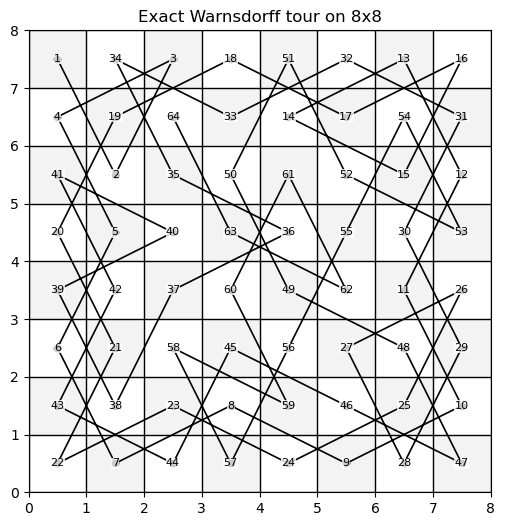

In [87]:
wd_result = warnsdorff_knights_tour(8, start=(0, 0), closed=False)

if wd_result["success"]:
    plot_tour(wd_result["tour"], 8, title="Exact Warnsdorff tour on 8x8")
    plt.show()

## 2.5. Neural-network method

The third approach is a **neural-network-based method**, inspired by the formulation presented in the Knight's Tour Wikipedia article.

In this framework, the problem is reformulated as a dynamical system. Each legal knight move is associated with a neuron, and each neuron can be either active or inactive. The network evolves iteratively until it reaches a stable state.

Let $N_{i,j}$ denote the neuron associated with a legal move from square $i$ to square $j$. For each neuron we define:

- $U_t(N_{i,j})$: its internal state at time $t$,
- $V_t(N_{i,j}) \in \{0,1\}$: its output at time $t$,
- $G(N_{i,j})$: the set of neurons interacting with $N_{i,j}$.

The state update rule is

$$U_{t+1}(N_{i,j})=U_t(N_{i,j})+ 2-\sum_{N\in G(N_{i,j})} V_t(N),$$

and the output update rule is

$$V_{t+1}(N_{i,j}) =
\begin{cases}
1, & U_{t+1}(N_{i,j}) > 3, \\[6pt]
0, & U_{t+1}(N_{i,j}) < 0, \\[6pt]
V_t(N_{i,j}), & \text{otherwise.}
\end{cases}
$$

The goal of this process is for the network to converge to a configuration in which the active neurons encode a valid knight's tour.

If convergence is achieved, the active set of neurons may represent either:

1. a valid knight's tour, or
2. several disconnected cycles or partial structures.

For this reason, the neural-network approach is best viewed as an experimental optimization-based method rather than a guaranteed constructive algorithm. Its mathematical interest lies in transforming a discrete combinatorial search problem into an iterative dynamical system.

In [52]:
def knight_arcs(n):
    """
    Return all directed legal knight moves on an n x n board.
    """
    G = knight_graph(n)
    return [(u, v) for u in G for v in G[u]]

In [53]:
def wikipedia_nn_tour(n, start=(0, 0), closed=False, max_epochs=400, restarts=30, seed=0):
    """
    Attempt to construct an open or closed knight's tour on an n x n board
    using a Wikipedia / Takefuji-Lee style neural-network interpretation.

    Parameters
    ----------
    n : int - Board dimension.
    start : tuple[int, int], default = (0, 0) - Preferred starting square of the returned tour.
    closed : bool, default = False - If True, require a closed knight's tour.
                                     If False, accept any Hamiltonian path; a Hamiltonian cycle is also accepted.
    max_epochs : int, default=400 - Maximum number of update sweeps per restart.
    restarts : int, default=30 - Number of random restarts.
    seed : int, default=0 - Random seed.

    Returns
    -------
    dict
        Dictionary containing:
        - "tour": list[tuple[int, int]] or None
        - "success": bool
        - "time": float
        - "epochs": int
        - "restarts": int
        - "method": str
        - "closed": bool
        - "n": int
    """
    if closed and (n < 6 or n % 2 == 1):
        raise ValueError("Closed tours on n x n boards require n even and n >= 6.")

    squares = all_squares(n)
    arcs = knight_arcs(n)
    arc_to_index = {arc: i for i, arc in enumerate(arcs)}

    incoming = {square: [] for square in squares}
    outgoing = {square: [] for square in squares}

    for u, v in arcs:
        outgoing[u].append((u, v))
        incoming[v].append((u, v))

    # For arc (a, b), neighbors are arcs sharing source a or target b.
    # Exclude the arc itself.
    neighbor_indices = []
    for a, b in arcs:
        neighbors = outgoing[a] + incoming[b]
        ids = [arc_to_index[arc] for arc in neighbors if arc != (a, b)]
        ids = list(dict.fromkeys(ids))
        neighbor_indices.append(np.array(ids, dtype=int))

    def decode_closed_cycle(V):
        """
        Decode active directed arcs into a single directed Hamiltonian cycle.
        """
        selected = [arcs[i] for i in range(len(arcs)) if V[i] == 1]

        out_map = {square: [] for square in squares}
        in_degree = {square: 0 for square in squares}

        for u, v in selected:
            out_map[u].append(v)
            in_degree[v] += 1

        if any(len(out_map[square]) != 1 for square in squares):
            return None
        if any(in_degree[square] != 1 for square in squares):
            return None

        cycle_start = start if start in out_map else squares[0]
        path = [cycle_start]
        seen = {cycle_start}
        current = cycle_start

        for _ in range(n * n - 1):
            next_square = out_map[current][0]
            if next_square in seen:
                return None
            seen.add(next_square)
            path.append(next_square)
            current = next_square

        if out_map[current][0] != cycle_start:
            return None

        if not is_valid_tour(path, n, closed=True):
            return None

        return path

    def decode_open_path(V):
        """
        Decode active directed arcs into a single directed Hamiltonian path.

        A cycle is also accepted here, since every closed tour is also an open tour
        when the closure condition is ignored.
        """
        selected = [arcs[i] for i in range(len(arcs)) if V[i] == 1]

        out_map = {square: [] for square in squares}
        in_degree = {square: 0 for square in squares}
        out_degree = {square: 0 for square in squares}

        for u, v in selected:
            out_map[u].append(v)
            out_degree[u] += 1
            in_degree[v] += 1

        # Allow the closed case too
        if all(out_degree[square] == 1 for square in squares) and all(in_degree[square] == 1 for square in squares):
            maybe_cycle = decode_closed_cycle(V)
            if maybe_cycle is not None and is_valid_tour(maybe_cycle, n, closed=False):
                return maybe_cycle

        starts = [square for square in squares if in_degree[square] == 0 and out_degree[square] == 1]
        ends = [square for square in squares if in_degree[square] == 1 and out_degree[square] == 0]
        middles_ok = all(
            (in_degree[square], out_degree[square]) == (1, 1)
            for square in squares
            if square not in starts and square not in ends
        )

        if len(starts) != 1 or len(ends) != 1 or not middles_ok:
            return None

        path_start = start if start in starts else starts[0]
        path = [path_start]
        seen = {path_start}
        current = path_start

        for _ in range(n * n - 1):
            if len(out_map[current]) != 1:
                return None
            next_square = out_map[current][0]
            if next_square in seen:
                return None
            seen.add(next_square)
            path.append(next_square)
            current = next_square

        if len(path) != n * n:
            return None

        if not is_valid_tour(path, n, closed=False):
            return None

        return path

    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    m = len(arcs)

    for restart in range(restarts):
        U = np.zeros(m, dtype=np.int64)
        V = rng.integers(0, 2, size=m, dtype=np.int8)

        for epoch in range(max_epochs):
            changed = 0

            # Asynchronous random updates
            for j in rng.permutation(m):
                U[j] = U[j] + 2 - int(V[neighbor_indices[j]].sum())

                if U[j] > 3:
                    new_value = 1
                elif U[j] < 0:
                    new_value = 0
                else:
                    new_value = int(V[j])

                if new_value != V[j]:
                    V[j] = new_value
                    changed += 1

            maybe_tour = decode_closed_cycle(V) if closed else decode_open_path(V)
            if maybe_tour is not None:
                return {
                    "tour": maybe_tour,
                    "success": True,
                    "time": time.perf_counter() - t0,
                    "epochs": epoch + 1,
                    "restarts": restart + 1,
                    "method": "Wikipedia NN",
                    "closed": closed,
                    "n": n,
                }

            if changed == 0:
                break

    return {
        "tour": None,
        "success": False,
        "time": time.perf_counter() - t0,
        "epochs": max_epochs,
        "restarts": restarts,
        "method": "Wikipedia NN",
        "closed": closed,
        "n": n,
    }

In [77]:
results = []

for seed in range(15):
    result = wikipedia_nn_tour(6, start=(0, 0), closed=True, restarts=200, seed=seed)
    results.append({
        "seed": seed,
        "success": result["success"],
        "time": result["time"],
        "epochs": result["epochs"],
        "restarts": result["restarts"],
        "tour_found": result["tour"] is not None
    })

df_nn_6x6 = pd.DataFrame(results)
df_nn_6x6

,seed,success,time,epochs,restarts,tour_found
0,0,False,0.171369,400,200,False
1,1,False,0.142887,400,200,False
2,2,False,0.134221,400,200,False
3,3,False,0.147726,400,200,False
4,4,False,0.148830,400,200,False
5,5,False,0.146850,400,200,False
6,6,False,0.149522,400,200,False
7,7,False,0.144564,400,200,False
8,8,False,0.145260,400,200,False
9,9,False,0.137180,400,200,False


The neural-network method is stochastic and does not guarantee convergence to a valid knight’s tour. It may instead converge to non-tour stable configurations or independent circuits, which explains repeated unsuccessful runs.

This claim is also supported by Ian Parberry’s analysis of the Takefuji–Lee network in his [research paper](https://ianparberry.com/pubs/knight3.pdf). It is stated in the abstract that experiments show the neural network has poor performance, and in the main text he explains why: although a knight’s tour is a stable configuration, other unusual subgraphs are also stable, so the system can settle into non-tour states. He also notes that the original Takefuji–Lee paper did not fully specify the initial and final conditions, and that the algorithm is randomized.

### 2.6. Analysis of the degree structure of the knight graph

The degree board shows, for each square of the chessboard, the number of legal knight moves available from that position. In graph-theoretic terms, this is the degree of the corresponding vertex in the knight graph. Formally, if a square is denoted by $(i,j)$, then its degree is

$$\deg(i,j)=\sum_{(\Delta i,\Delta j)\in\mathcal{M}}\mathbf{1}_{\{0\le i+\Delta i<n,\;0\le j+\Delta j<n\}},$$

where

$$\mathcal{M}=\{(\pm1,\pm2),(\pm2,\pm1)\}$$

is the set of all possible knight displacements.

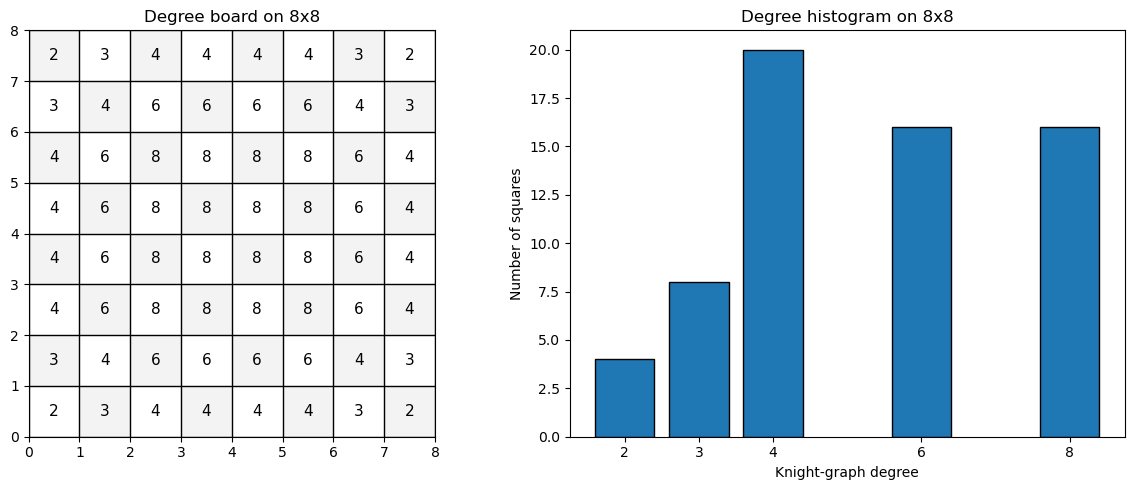

In [ ]:
A, degrees, fig, axes = plot_degree_analysis(8)
plt.show()

On an infinite board, every square would have degree $8$, since all knight moves would always remain available. On a finite $8\times 8$ board, however, boundary effects reduce the number of admissible moves. This is clearly visible in the degree board:

- the corner squares have degree $2$,
- the squares adjacent to corners along the edge have degree $3$,
- other edge and near-corner interior squares typically have degree $4$,
- squares one layer further inside often have degree $6$,
- only the central $4\times4$ region has the full degree $8$.

This pattern reflects a general principle: the closer a square is to the boundary, the fewer legal knight moves are available.

The histogram complements the board view by showing how many squares belong to each degree class. For the standard $8\times 8$ board, the distribution is:

- degree $2$: $4$ squares,
- degree $3$: $8$ squares,
- degree $4$: $20$ squares,
- degree $6$: $16$ squares,
- degree $8$: $16$ squares.

Thus, most squares do **not** have the maximum possible degree. The knight graph is therefore highly non-uniform: central squares are much more flexible, while corner and edge squares are strongly constrained.

This observation is directly relevant to the Knight's Tour problem. A knight's tour is a Hamiltonian path (or cycle) in this graph, so low-degree vertices are the most fragile part of the construction. If such constrained squares are postponed too long, they may become inaccessible later. This explains the intuition behind **Warnsdorff's heuristic**: at each step, it prefers moves toward squares with smaller onward degree, attempting to handle the most constrained regions early.

The degree distribution also provides a useful global graph invariant. By summing all vertex degrees, we obtain

$$
4\cdot 2 + 8\cdot 3 + 20\cdot 4 + 16\cdot 6 + 16\cdot 8 = 336.
$$

By the handshake lemma, the number of undirected edges in the knight graph is therefore

$$
|E|=\frac{336}{2}=168.
$$

Equivalently, if directed moves are counted separately, the graph contains $336$ directed arcs. This is especially relevant for the neural-network formulation, where one may associate neurons with directed knight moves.

Finally, the degree board highlights an important structural fact: the knight graph is sparse near the boundary and dense near the center. Any successful tour algorithm must therefore negotiate a delicate balance between preserving mobility in the middle of the board and ensuring that low-degree boundary squares are incorporated before they become unreachable.

# 3. Runtime growth for open tours

We now compare how the runtime of the backtracking algorithm and Warnsdorff's heuristic changes as the board size increases from $5 \times 5$ to $9 \times 9$ for the open knight's tour problem.

Since backtracking is an exact recursive search method, its runtime is expected to increase much more rapidly than that of Warnsdorff's heuristic, which is a greedy local method. The comparison below illustrates the difference in practical scalability between the two approaches.

In [90]:
sizes = list(range(5, 9))

backtracking_results = []
warnsdorff_results = []

for n in sizes:
    bt_result = backtracking_knights_tour(n, start=(0, 0), closed=False)
    backtracking_results.append({
        "n": n,
        "time": bt_result["time"],
        "success": bt_result["success"]
    })

    wd_result = warnsdorff_knights_tour(n, start=(0, 0), closed=False, seed=42)
    warnsdorff_results.append({
        "n": n,
        "time": wd_result["time"],
        "success": wd_result["success"]
    })

df_backtracking = pd.DataFrame(backtracking_results)
df_warnsdorff = pd.DataFrame(warnsdorff_results)

print("Backtracking results:")
display(df_backtracking)

print("Warnsdorff results:")
display(df_warnsdorff)

Backtracking results:


,n,time,success
0,5,0.018307,True
1,6,0.207791,True
2,7,5.727092,True
3,8,6.544675,True


Warnsdorff results:


,n,time,success
0,5,0.001039,True
1,6,0.000159,True
2,7,0.000199,True
3,8,0.000280,True


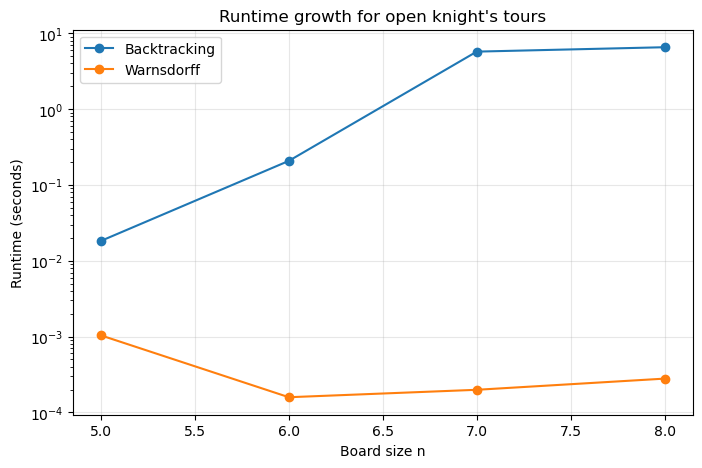

In [91]:
plt.figure(figsize=(8, 5))

plt.plot(df_backtracking["n"], df_backtracking["time"], marker="o", label="Backtracking")
plt.plot(df_warnsdorff["n"], df_warnsdorff["time"], marker="o", label="Warnsdorff")

plt.xlabel("Board size n")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime growth for open knight's tours")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The runtime comparison shows a clear contrast between the two methods. Backtracking, being an exact recursive search procedure, becomes rapidly more expensive as the board size increases. In contrast, Warnsdorff's heuristic remains extremely fast, since it makes only local degree-based decisions rather than exploring the full search tree.

This illustrates the main trade-off between the two approaches: backtracking is exact but computationally costly, whereas Warnsdorff's rule is heuristic but highly efficient in practice. The logarithmic runtime plot makes this difference especially clear, since the gap between the methods grows quickly as $n$ increases.